<a target="_blank" href="https://colab.research.google.com/github/seap-udea/fargopy/blob/main/examples/tutorials/fargopy-tutorial-flux.ipynb">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

<p align="left"><img src="https://github.com/seap-udea/fargopy/raw/refactor/docs/fargopy_logo.webp" width="300" /></p>

# Tutorial: accretion rates (mass flux)

In [1]:
try:
    from google.colab import drive
    %pip install -Uq git+https://github.com/seap-udea/fargopy
except ImportError:
    print("Not running in Colab, skipping installation")
    %load_ext autoreload
    %autoreload 2


Not running in Colab, skipping installation


This tutorial demonstrates how to compute surface and volume integrals on `FARGO3D` simulation data using `FARGOpy`. The notebook is organized as a clean, step-by-step guide with equations, brief explanations, and reproducible code examples. All plots are shown with no gridlines for clarity.

Key steps:
- Load a precomputed simulation
- Define a spherical surface around a planet
- Interpolate fields onto the surface
- Compute mass flux (accretion rate) and total mass
- Visualize the results in 2D and 3D

## Notebook structure

1. Requirements & imports
2. Load simulation data
3. Define surface and interpolation
4. Compute flux and total mass
5. Visualizations (3D scatter, Mollweide projection)

Equations used are provided inline where relevant.

## Requirements

Before starting, ensure you have the following modules installed:

- `fargopy`
- `numpy`
- `matplotlib`
- `pandas`
- `plotly`
- `cartopy` (for 2D projections)

If you are running this notebook in Google Colab, install the latest version of `fargopy` using the cell below.

*Note: The following calculations assume that the simulation is performed in a frame corotating with the planet of interest.*

In [2]:
import sys
import fargopy as fp
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import plotly.graph_objects as go
%load_ext autoreload
%autoreload 2




Running FARGOpy version 1.2.0.
NOTE: Since alpha versions (<=0.X.X) a major refactor has been done in versions 1.1.X.
Please check the documentation for more information.
The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Download and Load Simulation Data

First, list available precomputed simulations and download the 3D simulation of a disk with a Jovian planet.

In [3]:
# List available precomputed simulations (interactive)
fp.Simulation.list_precomputed()

fargo:
	Description: Protoplanetary disk with a Jovian planet [2D]
	Size: 55 MB
p3diso:
	Description: Protoplanetary disk with a Super earth planet [3D]
	Size: 220 MB
p3disoj:
	Description: Protoplanetary disk with a Jovian planet [3D]
	Size: 84 MB
fargo_multifluid:
	Description: Protoplanetary disk with several fluids (dust) and a Jovian planet in 2D
	Size: 100 MB
binary:
	Description: Disk around a binary with the properties of Kepler-38 in 2D
	Size: 140 MB
pds70iso:
	Description: PDS-70c - isothermal protoplanetary disk and circumplanetary disk in [3D]
	Size: 2940 MB


Download, for instance, the 3D simulation of a disk with a Jovian planet:

In [4]:
# Download an example 3D simulation (p3disoj) and set PATH
PATH = fp.Simulation.download_precomputed('p3disoj')

Precomputed output directory '/tmp/p3disoj' already exist


### Connect to the Simulation

Create a `Simulation` object by connecting it to the directory containing the simulation results.

In [5]:
# Connect to the simulation and set units to CGS for physical calculations
sim = fp.Simulation(output_dir=PATH)
sim.units('CGS')
sim.set_units(UL=1*sim.AU, UM=1*sim.MSUN)

Your simulation is now connected with '/home/fargopy/fargo3d/'
Now you are connected with output directory '/tmp/p3disoj'
Found a variables.par file in '/tmp/p3disoj', loading properties
Loading variables
85 variables loaded
Simulation in 3 dimensions
Loading domain in spherical coordinates:
	Variable phi: 128 [[0, np.float64(-3.117048960983623)], [-1, np.float64(3.117048960983623)]]
	Variable r: 64 [[0, np.float64(0.5078125)], [-1, np.float64(1.4921875)]]
	Variable theta: 32 [[0, np.float64(1.4231400767948967)], [-1, np.float64(1.5684525767948965)]]
Number of snapshots in output directory: 11
Planets found in summary.dat
  Name: Jupiter, Initial pos: [1.0, 0.001, 0.0], Mass: 0.001
Units set to CGS.


## Planet Properties
To access the orbital properties of the planets in the simulation, we make use of the `Simulation.Planet` module. This module provides direct access to the planet’s instantaneous position and velocity, its mass, and the corresponding Hill radius, which defines the spatial domain where the planet’s gravity dominates over that of the central star.

In [6]:
SNAP = 10

planets = sim.load_planets(snapshot = SNAP)
jupiter = planets[0]

In [7]:
type(jupiter)

fargopy.simulation.Planet

In [8]:

r_hill = jupiter.hill_radius

#Positions and velocities of the planet at snapshot SNAP in cartesian coordinates, and the planet mass
xp, yp, zp = jupiter.pos.x, jupiter.pos.y, jupiter.pos.z
vxp, vyp, vzp = jupiter.vel.x, jupiter.vel.y, jupiter.vel.z
Mass = jupiter.mass

## Surface tessellation and properties

We build a spherical surface (tessellated into triangles). Important attributes: `centers` (triangle centers), `areas` (triangle areas), and `normals`. These are used for interpolation and surface integration.

Create the `Sphere` object filtered for $z>0.03$ (semi-sphere)

In [9]:
sphere = fp.Surface(type='sphere',
    radius=r_hill,
    subdivisions=6,
    center=(xp, yp, zp),
    coords='spherical'
)

### Surface Properties

The sphere object has several important attributes:

- `sphere.centers`: Array of tessellation triangle centers in spherical coordinates.
- `sphere.areas`: Array of triangle areas.
- `sphere.volumes`: Array of triangle volumes.
- `sphere.normals`: Array of triangle normals in shperical coordinates.

These are used for interpolation and integration.

In [10]:
sphere.centers

array([[0.06005332, 0.96569392, 1.57016911],
       [0.05956686, 0.96486254, 1.56944925],
       [0.0602148 , 0.96602566, 1.56900687],
       ...,
       [0.02216917, 1.06431649, 1.57079633],
       [0.02325094, 1.06390674, 1.57145945],
       [0.02289178, 1.0640476 , 1.57079633]], shape=(81920, 3))

### Interpolate Fields on the Surface

Interpolate the simulation fields (e.g., density) onto the centers of the surface tessellation.

In [11]:
# Coordinates of the sphere centers in cartesian
phi_centers = sphere.centers[:, 0]
r_centers = sphere.centers[:, 1]
theta_centers = sphere.centers[:, 2]

First we can cut the data to the spherical region for flux calculation:

In [12]:
cut_sphere = (xp, yp, 0, 2*r_hill)

In [13]:
# Load the 3D gas density field from the simulation
data3d = sim.load_field(
    fields='gasdens',
    snapshot=SNAP,
    cut=cut_sphere,
    coords='spherical')



In [14]:
rho = data3d.evaluate(
   time=SNAP,
   var1=phi_centers,
   var2=r_centers,
   var3=theta_centers,
   reflect=True)  # Reflect along the mid-plane


### 3D view: interpolated density on surface centers

A quick 3D scatter of surface centers colored by log(density). No matplotlib grid is used; Plotly renders interactively.

First we need transform to cartesian for visualization

In [15]:
x_centers,y_centers,z_centers = fp.transform_coords('spherical', 'cartesian', phi_centers, r_centers, theta_centers)

In [16]:
fig = go.Figure(data=go.Scatter3d(
    x=x_centers.flatten()*sim.UL/fp.AU,
    y=y_centers.flatten()*sim.UL/fp.AU,
    z=z_centers.flatten()*sim.UL/fp.AU,
    mode='markers',
    marker=dict(size=2, color=np.log(rho.flatten()*sim.URHO), colorscale='Spectral_r', opacity=1, colorbar=dict(title='log10(ρ) [g cm−3]'))
))
fig.update_layout(scene=dict(xaxis_title='X [au]', yaxis_title='Y [au]', zaxis_title='Z [au]', aspectmode='data'), title='Interpolation on Sphere Surface Centers in 3D Gas Density Field')
fig.show()

## 2D Projection of Surface Data

Project the surface data onto a 2D map using Mollweide projection for easier visualization of the distribution.

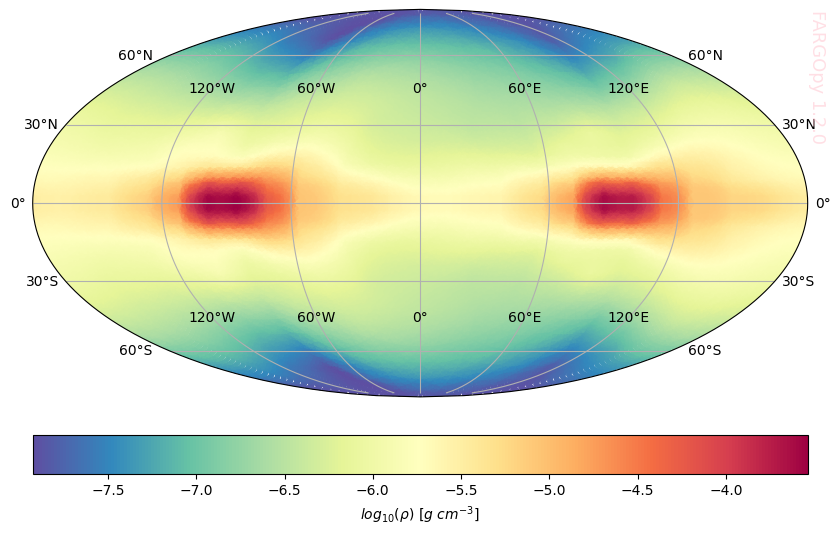

In [20]:
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

x0, y0, z0 = 1, 0, 0
xcs_shifted = x_centers - x0
ycs_shifted = y_centers - y0
zcs_shifted = z_centers - z0

# Calculate the spherical coordinates
r = np.sqrt(xcs_shifted**2 + ycs_shifted**2 + zcs_shifted**2)
lat = np.degrees(np.arcsin(zcs_shifted / r))
lon = np.degrees(np.arctan2(ycs_shifted, xcs_shifted))


fig = plt.figure(figsize=(10, 10))
ax = plt.axes(projection=ccrs.Mollweide())
sc = ax.scatter(
    lon, lat, c=np.log(rho), s=2, cmap='Spectral_r',
    transform=ccrs.PlateCarree(), alpha=1
)
# ax.coastlines()  # <- No mostrar contorno
ax.gridlines(draw_labels=True)
fp.Plot.fargopy_mark(ax)

plt.colorbar(sc, orientation='horizontal', pad=0.05, label=r'$log_{10}(\rho)~[g~cm^{-3}]$')

plt.savefig('gallery/fargopy-tutorial-flux_0.png') # Save figure
plt.show()


## Accretion rate (mass flux)

We compute the mass flux through a closed surface S around the planet. The mass flux (accretion rate) is:\n
$$\dot{M}=\int_S\rho(\mathbf{v}\cdot\hat{n})\,dS$$
where $\rho$ is the density, $\mathbf{v}$ the velocity vector and $\hat{n}$ the outward normal to the surface. We evaluate this integral by interpolating fields at triangle centers and summing $\rho (\mathbf{v}dotat{n}) A_{i}$ over tessellation triangles.

### Define Planet and Surface for Accretion Calculation

Set up the planet and surface objects for the accretion rate calculation.

In [21]:
snap = 10
jupiter = sim.load_planets(snapshot=snap)[0]
r_hill = jupiter.hill_radius
xp, yp, zp = jupiter.pos.x, jupiter.pos.y, jupiter.pos.z

sphere = fp.Surface(
    type='sphere',
    radius=r_hill,
    subdivisions=6,
    center=(xp, yp, zp),
    coords='spherical'
)

The computation is performed with `follow_planet=True`, ensuring that the integration surface co-moves with the planet. This choice is required because the Hill radius evolves in time as a consequence of planetary migration, and therefore the associated control volume must be updated consistently to remain centered on the planet.

In [22]:
flux = sphere.mass_flux(sim=sim, snapshot=[0,SNAP], follow_planet=True) 

Calculating mass flux: 100%|██████████| 11/11 [02:01<00:00, 11.08s/it]


Note: For faster interpolation, use the original coordinates in the `coords` parameter in `load_field` and `Surface`.

### Convert and Plot Accretion Rate

Convert the accretion rate to Jupiter masses per year and plot the result as a function of time.

In [23]:
Msunyr = 1.587e-26
Mjupyr = 1.662e-23

accretion = np.array(flux) * sim.UM / sim.UT * Mjupyr

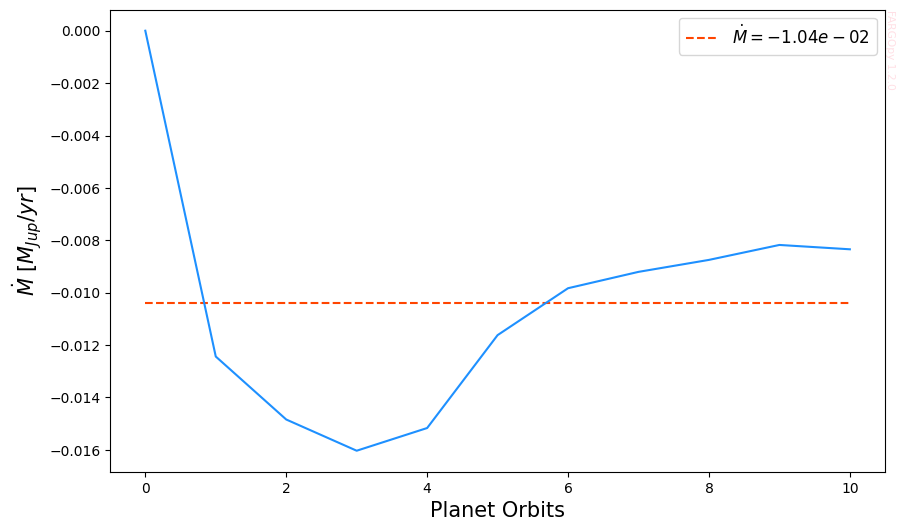

In [24]:
mean = accretion.mean()
ts = np.linspace(0, 10, len(accretion))

fig, ax = plt.subplots(figsize=(10, 6))
ax.hlines(mean, ts[0], ts[-1], colors='orangered', linestyles='--', label=r'$\dot{M}'+f' = {mean:.2e}$')
ax.plot(ts, accretion, color='dodgerblue')
ax.set_xlabel('Planet Orbits', size=15)
ax.set_ylabel(r'$\dot{M} \ [M_{Jup}/yr]$', size=15)
ax.legend(fontsize=12)
fp.Plot.fargopy_mark(ax)
plt.savefig('gallery/fargopy-tutorial-flux_1.png') # Save figure


## Matter flux heatmap in a single snapshot

Let's now look at a heat map on the surface of the sphere that shows us how the flow behaves on it. If the simulation is half-disk put z_cut=0, otherwise the reflect are only visual not physic.

In [25]:
SNAP = 10
jupiter = sim.load_planets(snapshot=SNAP)[0]
r_hill = jupiter.hill_radius
xp = jupiter.pos.x
yp = jupiter.pos.y
zp = jupiter.pos.z   

sphere = fp.Surface(type='sphere',
    radius=0.5*r_hill, 
    subdivisions=6, 
    center=(xp, yp, zp),
    coords='spherical')



### Load Density and Velocity Fields

Load both the density and velocity fields for the region around the planet to compute the local mass flux.

In [26]:
# Define cut region around the planet (x,y,z should be bounds or center coords)
sphere_cut = (xp, yp, zp, 2*r_hill)

data = sim.load_field(
    fields=['gasdens','gasv'],
    snapshot = SNAP,
    cut=sphere_cut,
    coords='spherical'
    )


### Interpolate Fields at Surface Centers

Interpolate the density and velocity fields at the centers of the surface tessellation triangles.

In [27]:
phi_centers = sphere.centers[:, 0]
r_centers = sphere.centers[:, 1]
theta_centers = sphere.centers[:, 2]



In [28]:


normals = sphere.normals

rho = data.evaluate(
    field='gasdens',
    time=SNAP,
    var1=phi_centers,
    var2=r_centers,
    var3=theta_centers,
    reflect=True)

vel = data.evaluate(
    field='gasv', 
    time=SNAP, 
    var1=phi_centers,
    var2=r_centers,
    var3=theta_centers,
    reflect=True)

In [29]:
# Extract velocity components (vel has shape (3, N))
vphi = vel[0, :]
vr = vel[1, :]
vtheta = vel[2, :]

vx, vy, vz = fp.transform_velocity(
    coord_in='spherical',      # Input coordinate system: 'spherical'
    coord_out='cartesian',     # Output coordinate system: 'cartesian'
    velocity=(vphi, vr, vtheta),  # Spherical velocity components (FARGO3D convention: phi first)
    position=(phi_centers, r_centers, theta_centers)  # Spherical coordinates where the velocity is defined
)

### Calculate Local Mass Flux

Compute the local mass flux at each triangle center using the dot product of velocity and surface normal, weighted by density and area.

In [30]:
v_dot_n = np.sum(vel * normals.T, axis=0)

# Local mass flux per triangle: rho * (v·n) with physical units
Ms = rho * v_dot_n * sim.UM / (sim.UL**2 * sim.UT)


In [31]:
import plotly.graph_objects as go

fig = go.Figure(
    data=go.Scatter3d(
        x=x_centers.flatten(),
        y=y_centers.flatten(),
        z=z_centers.flatten(),
        mode='markers',
        marker=dict(
            size=5,
            color=Ms,
            colorscale='RdBu_r',
            opacity=1,
            colorbar=dict(
                orientation='h',
                x=0.5,          # centered
                y=-0.18,        # below the scene
                len=0.5,        # bar length
                thickness=18,   # bar height (px)
                tickformat=".3f",
                title=dict(
                    text='ρ (v·n) [g cm⁻² s⁻¹] (inflow < 0, outflow > 0)',
                    side='top'
                )
            ),
        ),
    )
)

# ---- Layout control ----
fig.update_layout(
    width=700,            # wider canvas
    height=500,           # taller canvas (room for colorbar)
    margin=dict(
        l=40,
        r=40,
        t=40,
        b=140              # extra bottom margin for colorbar
    ),
    scene=dict(
        xaxis_title='X [au]',
        yaxis_title='Y [au]',
        zaxis_title='Z [au]',
        aspectmode='data',
        domain=dict(
            x=[0.0, 1.0],
            y=[0.15, 1.0]   # push 3D scene upward
        )
    ),
)

fig.show()


### 2D Projection of Mass Flux

Project the mass flux data onto a 2D map for easier interpretation of the accretion pattern.

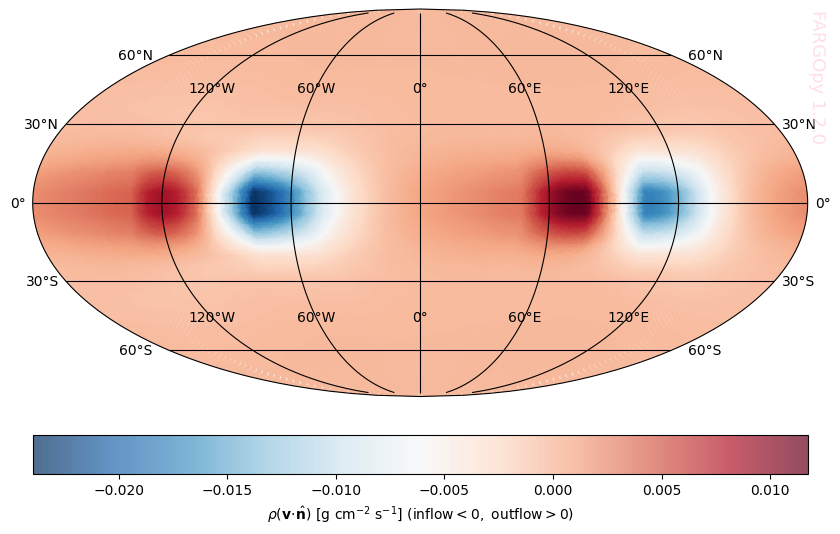

In [32]:
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs


x0, y0, z0 = xp, zp, 0
xcs_shifted = x_centers - x0
ycs_shifted = y_centers - y0
zcs_shifted = z_centers - z0


r = np.sqrt(xcs_shifted**2 + ycs_shifted**2 + zcs_shifted**2)
lat = np.degrees(np.arcsin(zcs_shifted / r))
lon = np.degrees(np.arctan2(ycs_shifted, xcs_shifted))


fig = plt.figure(figsize=(10, 10))
ax = plt.axes(projection=ccrs.Mollweide())
sc = ax.scatter(
    lon, lat, c=Ms, s=2, cmap='RdBu_r',
    transform=ccrs.PlateCarree(), alpha=0.7
)

ax.gridlines(draw_labels=True,color='black')
fp.Plot.fargopy_mark(ax)
plt.colorbar(sc, orientation='horizontal', pad=0.05, label=r"$\rho(\mathbf{v}\!\cdot\!\hat{\mathbf{n}})\ "
        r"[\mathrm{g\ cm^{-2}\ s^{-1}}]\ "
        r"(\mathrm{inflow}<0,\ \mathrm{outflow}>0)$")

plt.savefig('gallery/fargopy-tutorial-flux_2.png') # Save figure
plt.show()


## **Total Mass**

Now we can calculate the total mass accreted by the planet inside the sphere surface over the time.

In [33]:

jupiter = sim.load_planets(snapshot=snap)[0]
r_hill = jupiter.hill_radius
xp = jupiter.pos.x
yp = jupiter.pos.y
zp = jupiter.pos.z   

sphere = fp.Surface(type='sphere',
    radius=0.5*r_hill, 
    subdivisions=6, 
    center=(xp, yp, zp),
    z_cut=0.0,
    coords = 'spherical'
)

We multiply the result by a factor of two in order to recover the full spherical contribution, under the assumption of symmetry with respect to the disk midplane.

In [34]:
mass = 2*sphere.total_mass(
   sim=sim,
   snapshot=[0,10])   

Calculating total mass:  64%|██████▎   | 7/11 [00:00<00:00, 29.61it/s]

Calculating total mass: 100%|██████████| 11/11 [00:00<00:00, 30.21it/s]


In [35]:
mass = mass * sim.URHO * sim.UL**3  

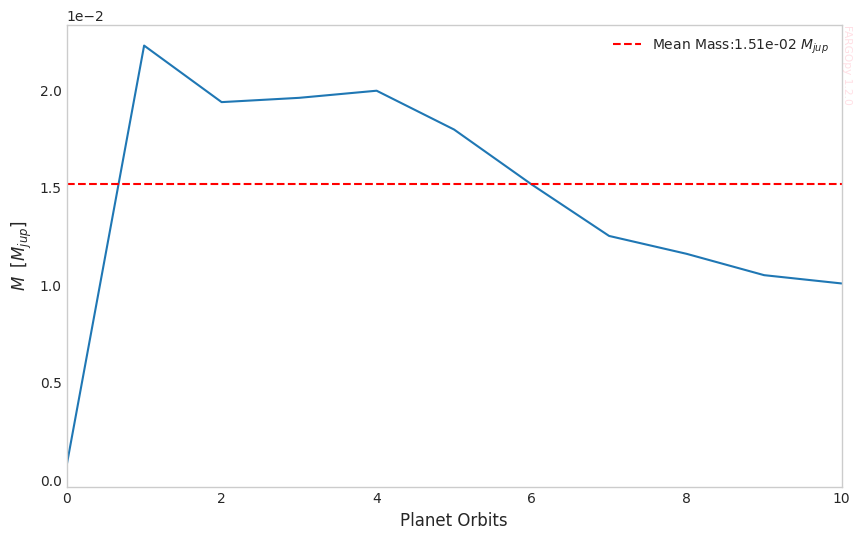

In [36]:
plt.style.use('seaborn-v0_8-whitegrid')
times = np.linspace(0, 10, 11)
Mjup = 1.989e27  # Jupiter mass Kg

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(times , np.array(mass) * 1e-3 / Mjup)
ax.hlines(
    y=np.median(np.array(mass) * 1e-3 / Mjup),
    xmin=0, xmax=10,
    color='r', linestyle='--',
    label=f'Mean Mass:{np.median(np.array(mass)*1e-3/Mjup):.2e} '+r'$M_{jup}$'
)
plt.xlabel('Planet Orbits', size=12)
plt.ylabel(r'$M_ \ [M_{jup}]$', size=12)
plt.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
plt.xlim(0, 10)
fp.Plot.fargopy_mark(ax)
plt.legend()
plt.grid(False)
plt.savefig('gallery/fargopy-tutorial-flux_3.png') # Save figure


---
*Powered by fargopy*. For more examples see [fargopy GitHub repo](https://github.com/seap-udea/fargopy/tree/main/examples). 

Jorge I. Zuluaga, Alejandro Murillo-González and Matías Montesinos © 2023-present
